# Imports

- **Replace Null Values in Age column**

### 4- Handle Outliers

- **Check for Outliers**

In [76]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [77]:
x = pd.read_csv('Titanic.csv')
x.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [78]:
x.drop(['PassengerId','Name', 'Ticket'], axis = 1, inplace= True)
x.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


## Chk datatype

In [79]:
dtypes = x.dtypes
n_uniq = x.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [80]:
def chk_types(data):
    dtypes = x.dtypes
    n_uniq = x.nunique()
    
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

In [81]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [82]:
chk_types_table(x)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Unique,2,3,2,88,7,7,248,147,3


In [83]:
cols = ['Pclass',
        'Survived',
        'Sex',
        'SibSp',
        'Parch',
        'Embarked']
x[cols] = x[cols].astype('category')


In [84]:
chk_types(x)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,str,category
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [85]:
x.shape[0]

891

In [86]:
null = x.isnull().sum()
ratio = (null/ x.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio %,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [87]:
median_1 = x['Age'].median()
x['Age'].fillna(median_1, inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [88]:
x.dropna(subset=['Embarked'], inplace= True)
x = x.drop("Cabin", axis=1)

In [89]:
null = x.isnull().sum()
ratio = (null/ x.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Null,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,19.910011,0.0,0.0,0.0,0.0


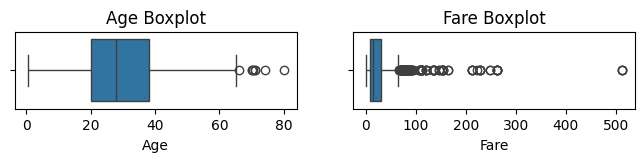

In [90]:
num_cols = x.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(x[col], orient="h")
    plt.title(f"{col} Boxplot")

In [91]:
for col in num_cols:
    Q1 = x[col].quantile(0.25)
    Q3 = x[col].quantile(0.75)
    IQR = Q3 - Q1
    # print(IQR)
    Lower_Fence = Q1 - 1.5*IQR
    Upper_Fence = Q3 + 1.5*IQR
    
    Lower_Outliers = x[x[col]< Lower_Fence][col].values
    Upper_Outliers = x[x[col] > Upper_Fence][col].values
    x[col] =x[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
    x[col] =x[col].replace(Upper_Outliers, Upper_Fence, inplace= True)

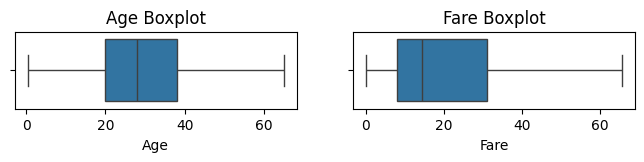

In [92]:
num_cols = x.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(x[col], orient="h")
    plt.title(f"{col} Boxplot")

In [93]:
x.duplicated().sum()

np.int64(120)

In [94]:
x.drop_duplicates(inplace= True)

In [95]:
x.duplicated().sum()

np.int64(0)

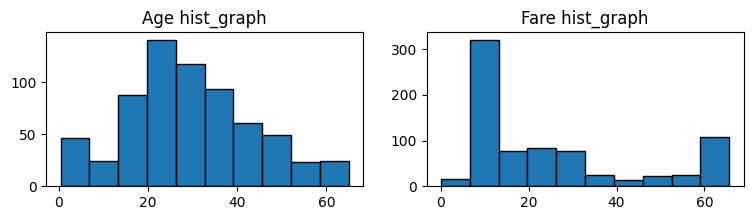

In [96]:
num_cols = x.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(x[col], edgecolor = "black")
    plt.title(f"{col} hist_graph")
plt.show()


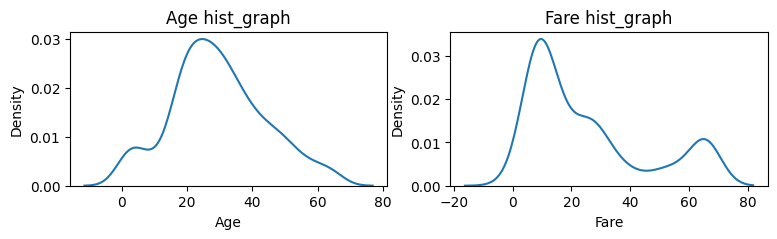

In [97]:
num_cols = x.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(x[col])
    plt.title(f"{col} hist_graph")
plt.show()

In [98]:
cat_cols = x.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

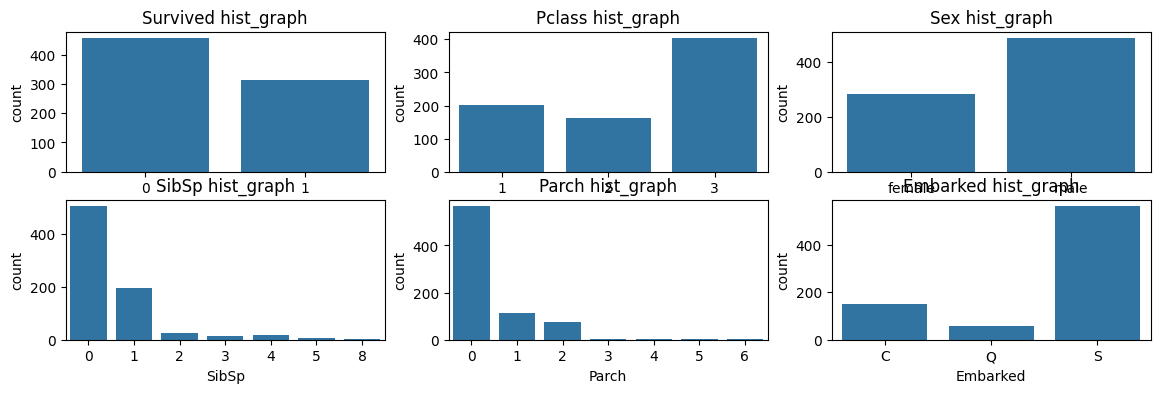

In [99]:
cat_cols = x.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = x)
    plt.title(f"{col} hist_graph")
plt.show()

In [100]:
unique = x['Pclass'].value_counts()
count = unique.values
print(unique)
print(count)

Pclass
3    403
1    203
2    163
Name: count, dtype: int64
[403 203 163]


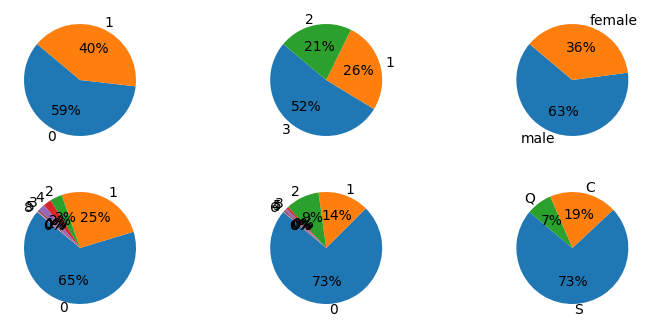

In [101]:
cat_cols = x.select_dtypes("category").columns

plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    unique = x[col].value_counts()
    count = unique.values
    categories =  unique.index
    plt.pie(count, labels=categories, startangle=140, autopct= '%1.1d%%')

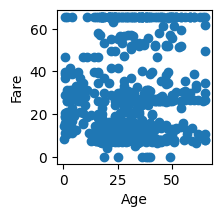

In [102]:
plt.figure(figsize=(2,2))
plt.scatter(x['Age'], x['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

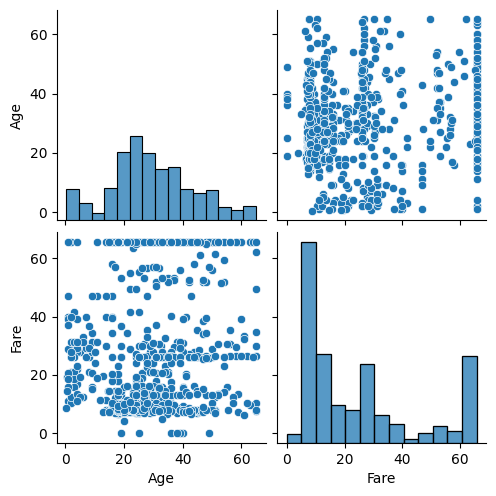

In [103]:
sns.pairplot(x)

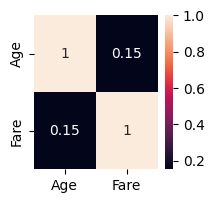

In [104]:
corr  =  x[num_cols].corr()

plt.figure(figsize=(2,2))
sns.heatmap(corr, annot=True)
plt.show()

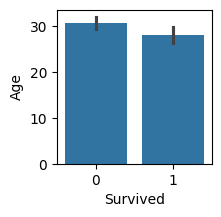

In [105]:
plt.figure(figsize=(2,2))
sns.barplot(x = "Survived", y="Age",data = x)
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

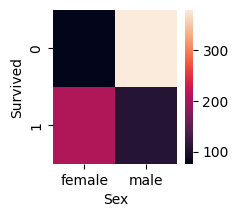

In [106]:
plt.figure(figsize=(2,2))
agg = x.pivot_table(index="Survived", columns="Sex",values="Age", aggfunc=len)
sns.heatmap(agg)


In [107]:
y = x["Survived"]
x = x.drop("Survived", axis=1)

In [108]:
y

0      0
1      1
2      1
3      1
4      0
      ..
885    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 769, dtype: category
Categories (2, int64): [0, 1]

In [109]:
# z = (x - median)/IQR
# target encoding vs label encoding

In [110]:
from sklearn.preprocessing import MinMaxScaler

In [111]:
num_cols = x.select_dtypes('number').columns
scaler = MinMaxScaler()
scaler.fit(x[num_cols])
x[num_cols] = scaler.fit_transform(x[num_cols])


In [112]:
from category_encoders import OneHotEncoder

str_cols = ["Sex", "Embarked"]
encoder = OneHotEncoder(cols=str_cols, drop_invariant=True)
x = encoder.fit_transform(x)

In [113]:
import numpy as np
import matplotlib.pyplot as plt

In [114]:
x = np.array([1,2,3,4])
y = np.array([2.2,2.8,3.6,4.5])

In [115]:
w = 0
b = 0